# Project Preliminary Report | Connor Oman
## Importing Data:

In [142]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

# Cleaning some malformed rows by using skip and engine = python
df = pd.read_csv("/content/games_to_march2025_raw.csv",on_bad_lines='skip',engine='python')

df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,488824,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


## Data Cleaning:

In [143]:
df.info()
print(" ")
df.describe(include='all')
print(" ")
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94948 entries, 0 to 94947
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     94948 non-null  int64  
 1   name                      94946 non-null  object 
 2   release_date              94948 non-null  object 
 3   required_age              94948 non-null  int64  
 4   price                     94948 non-null  float64
 5   dlc_count                 94948 non-null  int64  
 6   detailed_description      89522 non-null  object 
 7   about_the_game            89499 non-null  object 
 8   short_description         89599 non-null  object 
 9   reviews                   10428 non-null  object 
 10  header_image              94948 non-null  object 
 11  website                   41194 non-null  object 
 12  support_url               44185 non-null  object 
 13  support_email             78848 non-null  object 
 14  window

(94948, 47)

In [144]:
# Dropping unneeded columns
df = df.drop(df.columns[[10,11,12,13,14,15,16,18,23,29,30]], axis=1)

# Replacing missing numeric values with the mean for that column
df.fillna(df.mean(numeric_only=True), inplace=True)

# Replacing NaNs in categorical columns with Unrecorded
df[df.select_dtypes(include=["object"]).columns] = df[df.select_dtypes(include=["object"]).columns].fillna("Unrecorded")

# Checking for missingness
df.isna().sum()

,0
appid,0
name,0
release_date,0
required_age,0
price,0
dlc_count,0
detailed_description,0
about_the_game,0
short_description,0
reviews,0


In [145]:
# Removing duplicates
df = df.drop_duplicates()

# Converting release_date to pandas datetime
df["release_date"] = pd.to_datetime(df["release_date"])

# Saving the original before removing games where average_playtime_forever = 0
df_original = df.copy()

# Many games are barely interacted with by consumers
# Which makes some columns of the dataset very sparse
# Therefore, for the sake of the assignment, I decided to only use games that have a recorded average playtime
df = df[df["average_playtime_forever"] > 0]
print(df.shape)

# estimated_users is actually a range and a string (I.E. 100-2000)
# To make the column numeric, I took the average of the range
owners_split = df["estimated_owners"].str.split("-")

df["owners_low"] = owners_split.str[0].astype(int)
df["owners_high"] = owners_split.str[1].astype(int)

df["estimated_owners"] = (df["owners_low"]+df["owners_high"]) / 2

(8019, 36)


### Relevant Statistics from Numerical Columns
For this project, I'm primarily concerned with:
- positive
- negative
- estimated_owners
- average_playtime_forever
- median_playtime forever
- price
- review_ratio (added for sake of analysis)

In [146]:
# Adding a new column combining positive and negative
# towards 0 = a negatively reviewed game
# towards 1 = a positively reviewed game
df["review_ratio"] = df["positive"] / (df["positive"] + df["negative"])

# If there are zero positive or negative reviews, stopping it from dividing by zero
df["review_ratio"] = df["review_ratio"].replace([np.inf,-np.inf], np.nan)

relevant_columns = ["positive",
    "negative",
    "estimated_owners",
    "average_playtime_forever",
    "median_playtime_forever",
    "metacritic_score",
    "price","review_ratio"]

df[relevant_columns].describe(percentiles=[0.25, 0.5, 0.75, 0.9])

,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,metacritic_score,price,review_ratio
count,8.019000e+03,8.019000e+03,8.019000e+03,8.019000e+03,8.019000e+03,8019.000000,8019.000000,7826.000000
mean,9.031433e+03,1.449033e+03,6.200293e+05,1.285980e+03,1.283100e+03,15.466517,11.848545,0.780799
std,9.818226e+04,1.622574e+04,5.050763e+06,2.275021e+04,2.941712e+04,30.703869,12.385913,0.155336
min,0.000000e+00,0.000000e+00,1.000000e+04,1.000000e+00,1.000000e+00,0.000000,0.000000,0.000000
25%,1.640000e+02,4.500000e+01,3.500000e+04,6.400000e+01,6.000000e+01,0.000000,1.990000,0.699373
50%,6.390000e+02,1.390000e+02,7.500000e+04,2.180000e+02,2.130000e+02,0.000000,8.990000,0.816219
75%,2.602500e+03,4.690000e+02,3.500000e+05,5.110000e+02,4.430000e+02,0.000000,18.990000,0.899605
90%,1.082000e+04,1.768200e+03,7.500000e+05,1.436200e+03,1.108600e+03,77.000000,29.990000,0.945081
max,7.480813e+06,1.135108e+06,3.500000e+08,1.462997e+06,1.462997e+06,97.000000,99.990000,1.000000


### Outlier Checks:

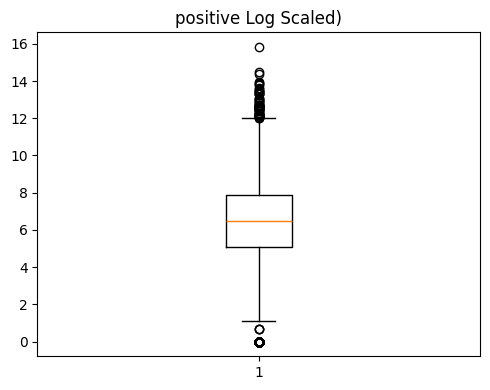

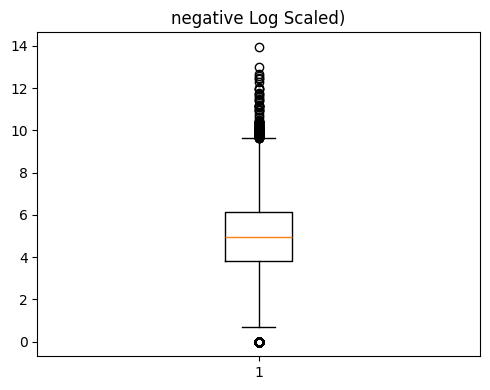

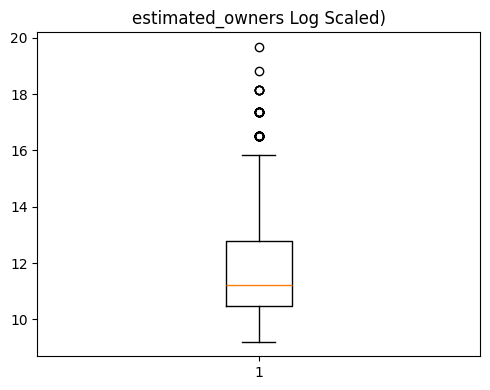

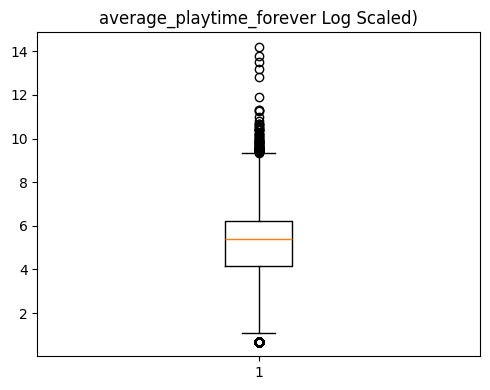

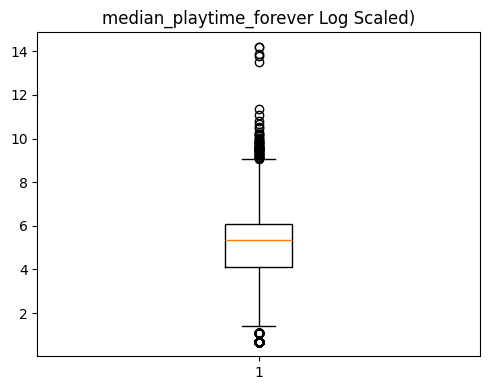

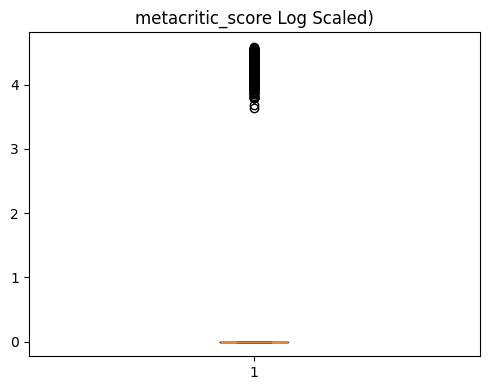

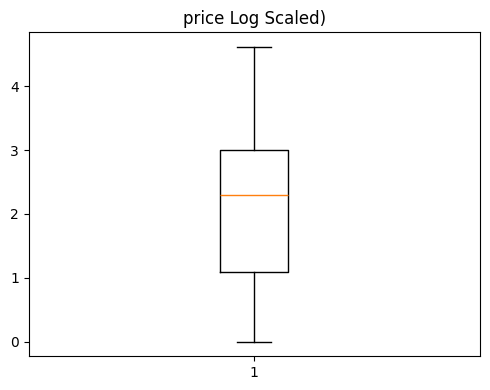

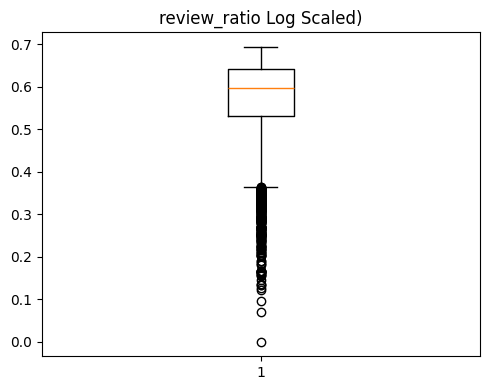

In [147]:
for i in relevant_columns:
    plt.figure(figsize=(5, 4))

    plt.boxplot(np.log1p(df[i].dropna()))
    plt.title(f"{i} Log Scaled)")
    plt.tight_layout()
    plt.show()

In [148]:
df_no_outliers = df.copy()

# Removing outliers
for i in relevant_columns:
    q_low = df_no_outliers[i].quantile(0.01)
    q_up = df_no_outliers[i].quantile(0.99)

    # Setting up the range
    q_range = q_up - q_low
    low = q_low - 1.5 * q_range
    up = q_up + 1.5 * q_range

    # Keep only non-outliers
    df_no_outliers = df_no_outliers[
        (df_no_outliers[i] >= low) & (df_no_outliers[i] <= up)]

df_no_outliers.shape

(7728, 39)

## Number of Games Being Released Each Year:
### Subsetted Dataset: (playtime > 0)

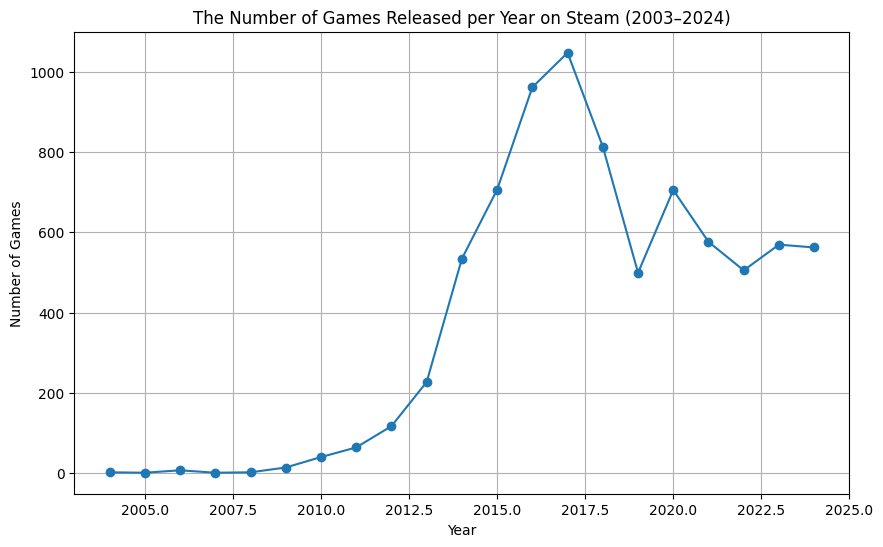

In [149]:
# Filter years
df["release_year"] = df["release_date"].dt.year
games_per_year = df[(df["release_year"] >= 2003) & (df["release_year"] <= 2024)]

# Counting games per year
games_per_year = games_per_year["release_year"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(games_per_year.index, games_per_year.values, marker='o')

plt.title("The Number of Games Released per Year on Steam (2003–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.grid(True)
plt.show()

### Original Dataset: (playtime =< 0)

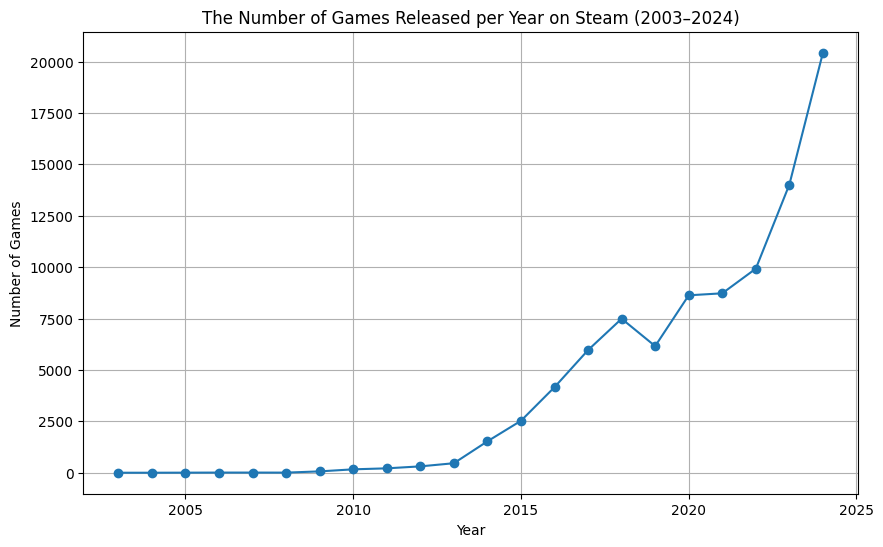

In [150]:
# Filter years
df_original["release_year"] = df_original["release_date"].dt.year
games_per_year = df_original[(df_original["release_year"] >= 2003) & (df_original["release_year"] <= 2024)]

# Counting games per year
games_per_year = games_per_year["release_year"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(games_per_year.index, games_per_year.values, marker='o')

plt.title("The Number of Games Released per Year on Steam (2003–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.grid(True)
plt.show()

## Predicting the Review Ratio:

In [151]:
numerical_columns = ['average_playtime_forever', 'metacritic_score', 'price']
text_columns = ['tags', 'genres']

df_no_nan = df.dropna(subset=numerical_columns + text_columns + ['review_ratio']).copy()

y = df_no_nan['review_ratio']

# Converting to string
df_no_nan['tags'] = df_no_nan['tags'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
df_no_nan['genres'] = df_no_nan['genres'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_columns),
    ('tags', TfidfVectorizer(max_features=800), 'tags'),
    ('genres', TfidfVectorizer(max_features=200), 'genres')])

# Model pipeline
model = Pipeline([('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10.0))])

# Splitting
X = df_no_nan[numerical_columns + text_columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting
model.fit(X_train, y_train)

# Evaluating
y_pred = model.predict(X_test)

# Cross Validation
cv = cross_val_score(model,X,y,cv=5,scoring='r2')

print("Cross-Validation R-squared Scores:", cv)
print("Average R-squared:", np.mean(cv))

print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

Cross-Validation R-squared Scores: [-0.1723381   0.11288984  0.13287191  0.12566162 -0.29590925]
Average R-squared: -0.01936479711645973
R-squared: 0.30043487275212066
RMSE: 0.017736631058088842


In [152]:
# Calculating the influence numeric columns have on the outcome
model_num = Ridge().fit(X_train[numerical_columns], y_train)
print(model_num.score(X_test[numerical_columns], y_test))

0.03160701113785924


###Which tags and genres appear the most often with positively reviewed games?

In [153]:
# Key Functions:
import ast
from collections import Counter

def extract_terms(series):
    terms = []
    for row in series:
        # Ensuring it's a string
        if not isinstance(row, str):
            continue
        try:
            parsed = ast.literal_eval(row)
            # If dictionary: use the keys
            if isinstance(parsed, dict):
                terms.extend(parsed.keys())
            # If list: use values directly
            elif isinstance(parsed, list):
                terms.extend(parsed)
            else:
                terms.extend(row.split())
        except:
            # If the parsing fails
            terms.extend(row.split())

    return terms

# I need to ensure I'm accounting for the occurence of specific tags and genre
# in the dataset in terms of performance.
def get_top_relative_terms(group_series, total_series, top_n=30, min_count=20):
    total_counts = Counter(extract_terms(total_series))
    group_counts = Counter(extract_terms(group_series))
    scores = {term: group_counts[term] / total_counts[term]
        for term in total_counts
        if total_counts[term] >= min_count}
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

In [154]:
# Defining thresholds
high_threshold = df_no_nan['review_ratio'].quantile(0.75)
low_threshold = df_no_nan['review_ratio'].quantile(0.25)

high_df = df_no_nan[df_no_nan['review_ratio'] >= high_threshold]
low_df = df_no_nan[df_no_nan['review_ratio'] <= low_threshold]

# Top tags according to review_ratio
top_high_tags_review = get_top_relative_terms(high_df['tags'], df_no_nan['tags'])
top_low_tags_review = get_top_relative_terms(low_df['tags'], df_no_nan['tags'])

# Top genres according to review_ratio
top_high_genres_review = get_top_relative_terms(high_df['genres'], df_no_nan['genres'])
top_low_genres_review = get_top_relative_terms(low_df['genres'], df_no_nan['genres'])

print("Top 30 Tags with [High Review Ratio]:")
print(top_high_tags_review)
print("\nTop 30 Genres with [High Review Ratio]:")
print(top_high_genres_review)
print("\nTop 30 Tags with [Low Review Ratio]:")
print(top_low_tags_review)
print("\nTop 30 Genres with [Low Review Ratio]:")
print(top_low_genres_review)

Top 30 Tags with [High Review Ratio]:
[('Cozy', 0.6), ('Faith', 0.59375), ('Creature Collector', 0.5849056603773585), ('Collectathon', 0.5813953488372093), ('Cats', 0.5625), ('Wholesome', 0.5471698113207547), ('Foreign', 0.5416666666666666), ('Boomer Shooter', 0.5135135135135135), ('Programming', 0.5094339622641509), ('Philosophical', 0.5), ('Emotional', 0.49099099099099097), ('Romance', 0.4888888888888889), ('Multiple Endings', 0.4801864801864802), ('Time Travel', 0.4772727272727273), ('Minimalist', 0.4755244755244755), ('Minigames', 0.4666666666666667), ('Cute', 0.46325581395348836), ('Narrative', 0.46296296296296297), ('LGBTQ+', 0.4624277456647399), ('Dating Sim', 0.4612676056338028), ('Dark Comedy', 0.4523809523809524), ('Surreal', 0.45121951219512196), ('Abstract', 0.45), ('Visual Novel', 0.4496753246753247), ('Conversation', 0.44144144144144143), ('Sokoban', 0.44), ('Precision Platformer', 0.43956043956043955), ('Psychedelic', 0.4375), ('Psychological', 0.43703703703703706), ('Sc

### Predicting the Estimated Owners:

In [155]:
numerical_columns = ['average_playtime_forever', 'metacritic_score', 'price']
text_columns = ['tags', 'genres']

df_no_nan = df.dropna(subset=numerical_columns + text_columns + ['review_ratio']).copy()

# Doing a log transformation because the dataset is extremely skewed
y = np.log1p(df_no_nan['estimated_owners'])

# Converting to string
df_no_nan['tags'] = df_no_nan['tags'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
df_no_nan['genres'] = df_no_nan['genres'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_columns),
    ('tags', TfidfVectorizer(max_features=800), 'tags'),
    ('genres', TfidfVectorizer(max_features=200), 'genres')])

# Model pipeline
model = Pipeline([('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10.0))])

# Train/test split
X = df_no_nan[numerical_columns + text_columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

# Cross Validation
cv = cross_val_score(model,X,y,cv=5,scoring='r2')

print("Cross-Validation R-squared scores:", cv)
print("Average R-squared:", np.mean(cv))

print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

Cross-Validation R-squared scores: [-2.97316265 -0.48050826 -0.37105806 -0.69747064 -0.538232  ]
Average R-squared: -1.012086322496375
R-squared: 0.419533683066447
RMSE: 1.6384231569816194


In [156]:
# Calculating the influence numeric columns have on the outcome
model_num = Ridge().fit(X_train[numerical_columns], y_train)
print(model_num.score(X_test[numerical_columns], y_test))

0.10921179046338081


### Which tags and genres appear the most frequently in popular games?

In [157]:
high_threshold = df_no_nan['estimated_owners'].quantile(0.75)
low_threshold = df_no_nan['estimated_owners'].quantile(0.25)

high_df = df_no_nan[df_no_nan['estimated_owners'] >= high_threshold]
low_df = df_no_nan[df_no_nan['estimated_owners'] <= low_threshold]

# Top tags according to estimated_owners
top_high_tags_owners = get_top_relative_terms(high_df['tags'], df_no_nan['tags'])
top_low_tags_owners = get_top_relative_terms(low_df['tags'], df_no_nan['tags'])

# Top genres according to estimated_owners
top_high_genres_owners = get_top_relative_terms(high_df['genres'], df_no_nan['genres'])
top_low_genres_owners = get_top_relative_terms(low_df['genres'], df_no_nan['genres'])

print("Top 30 Tags with [High Estimated Owners]:")
print(top_high_tags_owners)
print("\nTop 30 Genres with [High Estimated Owners]:")
print(top_high_genres_owners)
print("\nTop 30 Tags with [Low Estimated Owners]:")
print(top_low_tags_owners)
print("\nTop 30 Genres with [Low Estimated Owners]:")
print(top_low_genres_owners)

Top 30 Tags with [High Estimated Owners]:
[('Mod', 0.9090909090909091), ('Epic', 0.7560975609756098), ('Looter Shooter', 0.7333333333333333), ('Sniper', 0.7272727272727273), ('MMORPG', 0.6859504132231405), ('Class-Based', 0.676923076923077), ('Hero Shooter', 0.6666666666666666), ('Assassin', 0.6666666666666666), ('Massively Multiplayer', 0.665680473372781), ('Moddable', 0.6651162790697674), ('Heist', 0.6585365853658537), ('LEGO', 0.6538461538461539), ('Vikings', 0.65), ('Games Workshop', 0.6486486486486487), ('Online Co-Op', 0.6387665198237885), ('Escape Room', 0.6349206349206349), ('Co-op', 0.6269035532994924), ('Open World', 0.6137750653879687), ('Third-Person Shooter', 0.6077586206896551), ('Remake', 0.6065573770491803), ('Warhammer 40K', 0.6), ('Battle Royale', 0.5932203389830508), ('Multiplayer', 0.5926463473633284), ('Superhero', 0.58), ('Team-Based', 0.5795454545454546), ('3D Vision', 0.575), ('MOBA', 0.5714285714285714), ('Third Person', 0.5702179176755447), ('Gun Customization

### Result Charts:

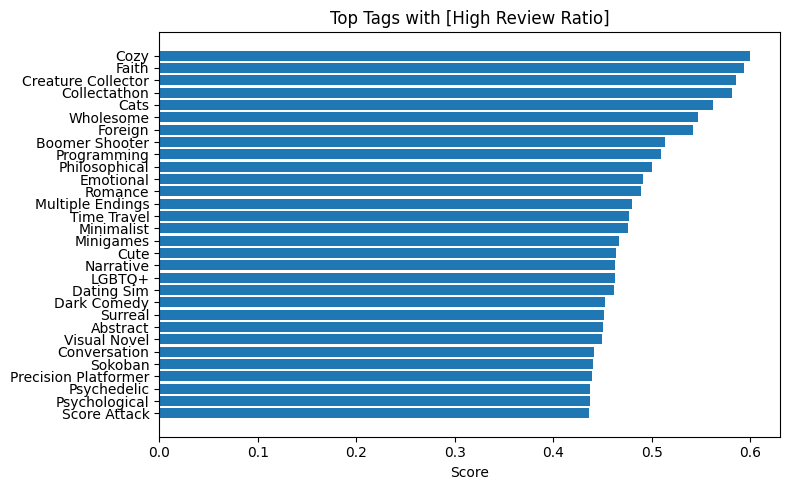

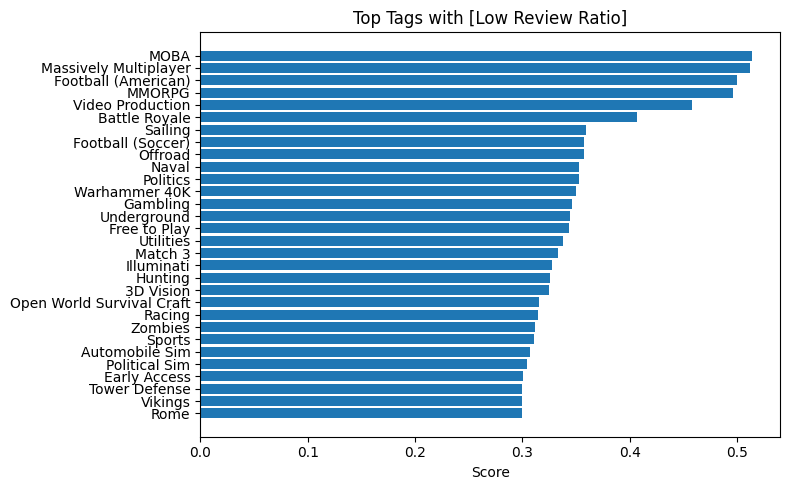

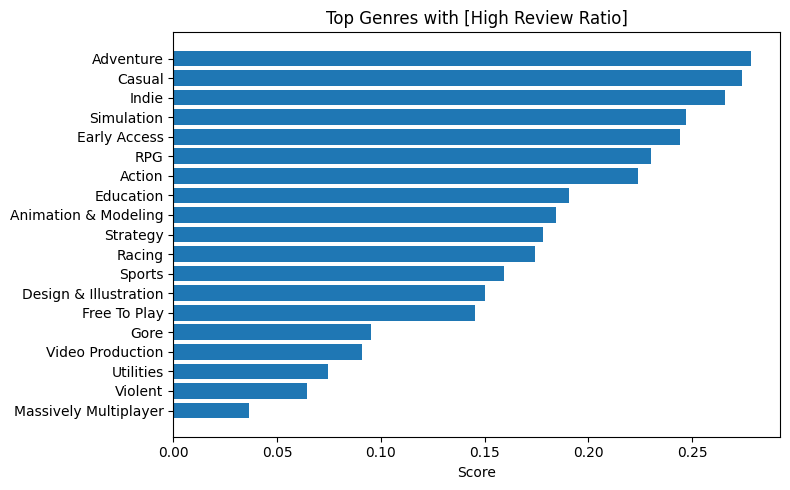

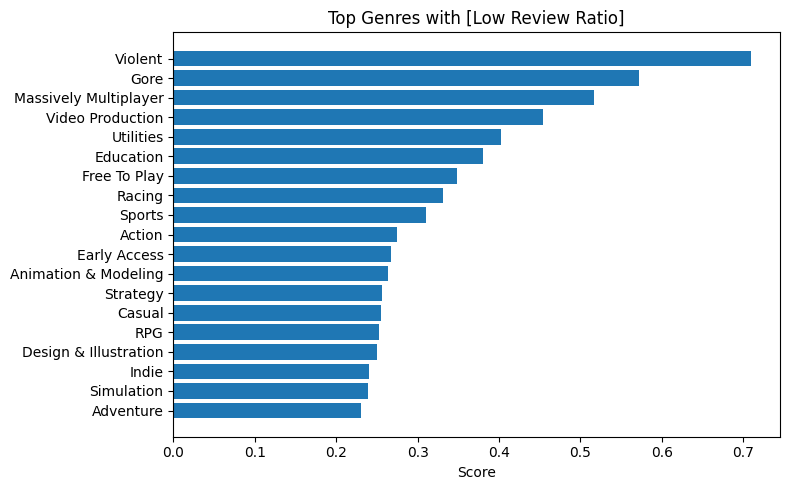

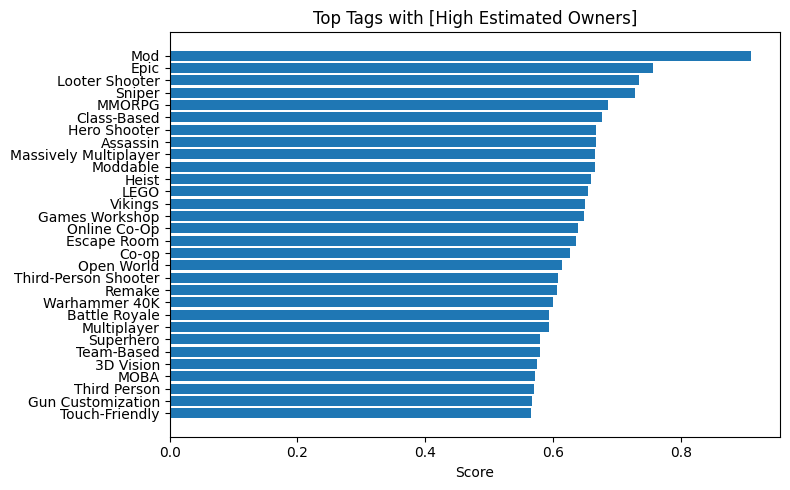

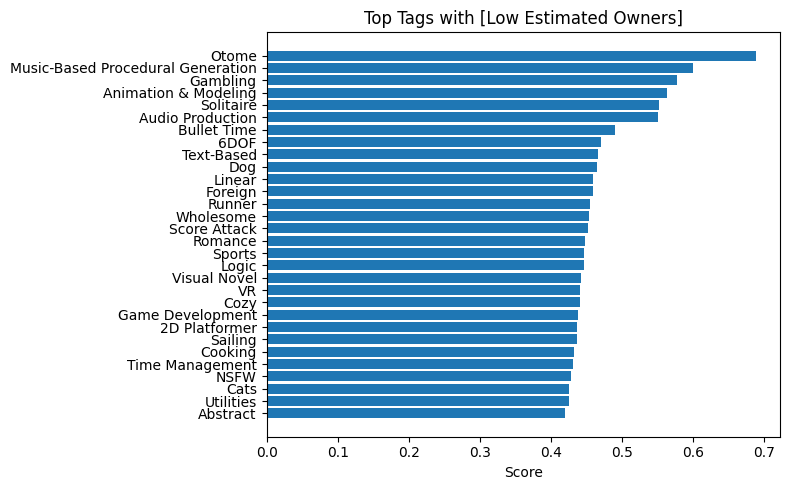

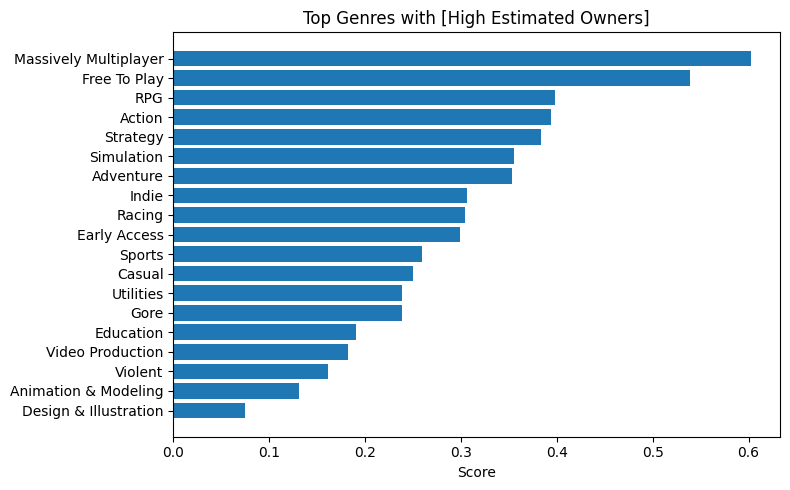

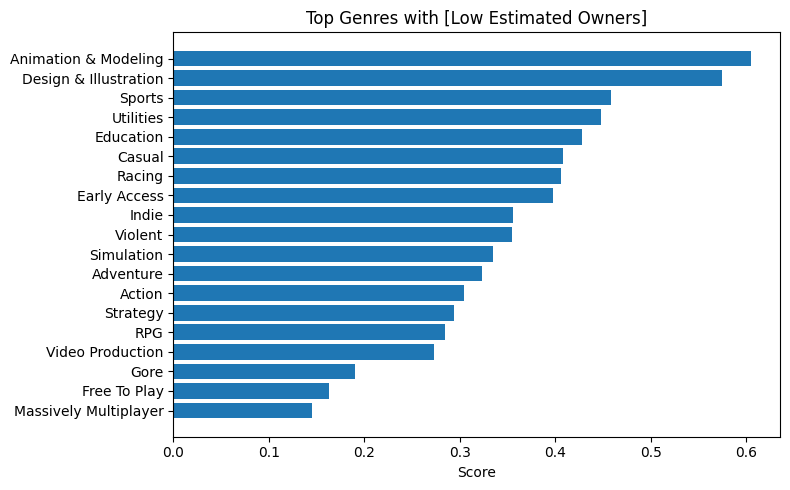

In [158]:
def plot_terms(top_list, title):
    terms = [term for term, _ in top_list]
    values = [score for _, score in top_list]
    plt.figure(figsize=(8, 5))
    plt.barh(terms[::-1], values[::-1])
    plt.xlabel("Score")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Example usage
plot_terms(top_high_tags_review, "Top Tags with [High Review Ratio]")
plot_terms(top_low_tags_review, "Top Tags with [Low Review Ratio]")

plot_terms(top_high_genres_review, "Top Genres with [High Review Ratio]")
plot_terms(top_low_genres_review, "Top Genres with [Low Review Ratio]")

plot_terms(top_high_tags_owners, "Top Tags with [High Estimated Owners]")
plot_terms(top_low_tags_owners, "Top Tags with [Low Estimated Owners]")

plot_terms(top_high_genres_owners, "Top Genres with [High Estimated Owners]")
plot_terms(top_low_genres_owners, "Top Genres with [Low Estimated Owners]")

## Genre and Tag Performance Relative to Market Saturation:

In [159]:
# Extrating terms to build a trend
def build_trends(df, text_col, top_lists):
    trends = {}

    # Extracting the terms directly from each list defined previously
    terms = [i for lst in top_lists for i, _ in lst]

    for i in terms:
        mask = df[text_col].astype(str).str.contains(i, regex=False, na=False)
        trends[i] = (
            df[mask]
            .groupby('release_year')
            .agg(volume=(text_col, 'size'),
                review_ratio=('review_ratio', 'mean'),
                estimated_owners=('estimated_owners', 'mean')))
    return trends


# Printing correlation
def print_trend_correlations(title, trends):
    print(f"\n- {title} -")
    for i, yearly_data in trends.items():
        cor = yearly_data[['volume','review_ratio', 'estimated_owners']].corr()
        vol_review = cor.loc['volume', 'review_ratio']
        vol_owners = cor.loc['volume', 'estimated_owners']

        print(f"\n{i}")
        print(f"Volume vs Review Ratio: {vol_review:.3f}")
        print(f"Volume vs Estimated Owners: {vol_owners:.3f}")

In [160]:
# Using the build_trends function for each measurement of success
review_tag_trends = build_trends(df_no_nan, 'tags',
    [top_high_tags_review,top_low_tags_review])

review_genre_trends = build_trends(df_no_nan, 'genres',
    [top_high_genres_review,top_low_genres_review])

owners_tag_trends = build_trends(df_no_nan, 'tags',
    [top_high_tags_owners,top_low_tags_owners])

owners_genre_trends = build_trends(df_no_nan, 'genres',
    [top_high_genres_owners,top_low_genres_owners])

In [161]:
print_trend_correlations("TAGS based on Review Score", review_tag_trends)


- TAGS based on Review Score -

Cozy
Volume vs Review Ratio: -0.441
Volume vs Estimated Owners: -0.369

Faith
Volume vs Review Ratio: 0.030
Volume vs Estimated Owners: 0.330

Creature Collector
Volume vs Review Ratio: 0.286
Volume vs Estimated Owners: -0.211

Collectathon
Volume vs Review Ratio: 0.476
Volume vs Estimated Owners: 0.212

Cats
Volume vs Review Ratio: 0.018
Volume vs Estimated Owners: 0.506

Wholesome
Volume vs Review Ratio: -0.260
Volume vs Estimated Owners: -0.085

Foreign
Volume vs Review Ratio: -0.244
Volume vs Estimated Owners: -0.001

Boomer Shooter
Volume vs Review Ratio: 0.430
Volume vs Estimated Owners: -0.442

Programming
Volume vs Review Ratio: 0.072
Volume vs Estimated Owners: -0.244

Philosophical
Volume vs Review Ratio: -0.038
Volume vs Estimated Owners: -0.287

Emotional
Volume vs Review Ratio: 0.125
Volume vs Estimated Owners: -0.316

Romance
Volume vs Review Ratio: 0.105
Volume vs Estimated Owners: -0.290

Multiple Endings
Volume vs Review Ratio: 0.417
Vo

In [162]:
print_trend_correlations("GENRES based on Review Score", review_genre_trends)


- GENRES based on Review Score -

Adventure
Volume vs Review Ratio: -0.557
Volume vs Estimated Owners: -0.331

Casual
Volume vs Review Ratio: -0.541
Volume vs Estimated Owners: -0.282

Indie
Volume vs Review Ratio: -0.579
Volume vs Estimated Owners: -0.306

Simulation
Volume vs Review Ratio: -0.122
Volume vs Estimated Owners: -0.298

Early Access
Volume vs Review Ratio: 0.068
Volume vs Estimated Owners: -0.467

RPG
Volume vs Review Ratio: -0.337
Volume vs Estimated Owners: -0.350

Action
Volume vs Review Ratio: -0.698
Volume vs Estimated Owners: -0.390

Education
Volume vs Review Ratio: -0.596
Volume vs Estimated Owners: -0.169

Animation & Modeling
Volume vs Review Ratio: -0.312
Volume vs Estimated Owners: -0.173

Strategy
Volume vs Review Ratio: -0.064
Volume vs Estimated Owners: -0.171

Racing
Volume vs Review Ratio: -0.684
Volume vs Estimated Owners: 0.028

Sports
Volume vs Review Ratio: -0.213
Volume vs Estimated Owners: -0.127

Design & Illustration
Volume vs Review Ratio: -0.24

In [163]:
print_trend_correlations("TAGS based on Estimated Owners", owners_tag_trends)


- TAGS based on Estimated Owners -

Mod
Volume vs Review Ratio: -0.671
Volume vs Estimated Owners: -0.356

Epic
Volume vs Review Ratio: -0.383
Volume vs Estimated Owners: -0.067

Looter Shooter
Volume vs Review Ratio: -0.075
Volume vs Estimated Owners: -0.374

Sniper
Volume vs Review Ratio: -0.502
Volume vs Estimated Owners: -0.225

MMORPG
Volume vs Review Ratio: -0.261
Volume vs Estimated Owners: -0.253

Class-Based
Volume vs Review Ratio: 0.129
Volume vs Estimated Owners: -0.096

Hero Shooter
Volume vs Review Ratio: 0.301
Volume vs Estimated Owners: 0.397

Assassin
Volume vs Review Ratio: -0.161
Volume vs Estimated Owners: -0.321

Massively Multiplayer
Volume vs Review Ratio: -0.493
Volume vs Estimated Owners: -0.271

Moddable
Volume vs Review Ratio: -0.589
Volume vs Estimated Owners: -0.335

Heist
Volume vs Review Ratio: -0.444
Volume vs Estimated Owners: -0.296

LEGO
Volume vs Review Ratio: 0.300
Volume vs Estimated Owners: -0.202

Vikings
Volume vs Review Ratio: -0.039
Volume vs 

In [164]:
print_trend_correlations("GENRES based on Estimated Owners", owners_genre_trends)


- GENRES based on Estimated Owners -

Massively Multiplayer
Volume vs Review Ratio: -0.380
Volume vs Estimated Owners: -0.247

Free To Play
Volume vs Review Ratio: -0.439
Volume vs Estimated Owners: -0.293

RPG
Volume vs Review Ratio: -0.337
Volume vs Estimated Owners: -0.350

Action
Volume vs Review Ratio: -0.698
Volume vs Estimated Owners: -0.390

Strategy
Volume vs Review Ratio: -0.064
Volume vs Estimated Owners: -0.171

Simulation
Volume vs Review Ratio: -0.122
Volume vs Estimated Owners: -0.298

Adventure
Volume vs Review Ratio: -0.557
Volume vs Estimated Owners: -0.331

Indie
Volume vs Review Ratio: -0.579
Volume vs Estimated Owners: -0.306

Racing
Volume vs Review Ratio: -0.684
Volume vs Estimated Owners: 0.028

Early Access
Volume vs Review Ratio: 0.068
Volume vs Estimated Owners: -0.467

Sports
Volume vs Review Ratio: -0.213
Volume vs Estimated Owners: -0.127

Casual
Volume vs Review Ratio: -0.541
Volume vs Estimated Owners: -0.282

Utilities
Volume vs Review Ratio: -0.374
Vo

###Plot Generator for Saturation:

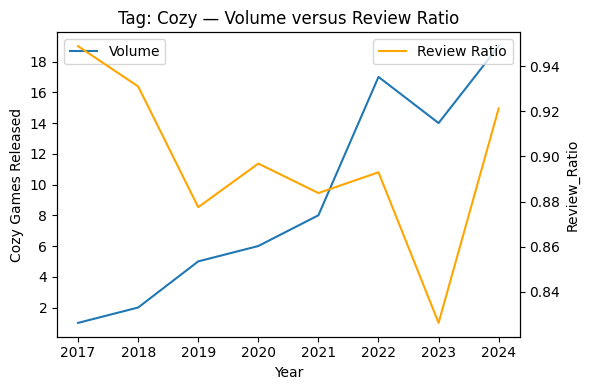

In [165]:
# Choose genre or tag to generate plot for
item = 'Cozy'

# Choose between 'review_ratio' or 'estimated_owners'
# In this context estimated owners refers to the average owners of the games
# with that tag or genre released within that year.
metric = 'review_ratio'

# Automatically confirm data type
if item in owners_tag_trends:
    data = owners_tag_trends[item]
    label = "Tag"
elif item in owners_genre_trends:
    data = owners_genre_trends[item]
    label = "Genre"
else:
    raise ValueError(f"{item} not found in trends")

# The data for 2025 is incomplete so it should be removed
data = data[data.index != 2025]

# Plotting
fig, ax1 = plt.subplots(figsize=(6,4))

# Volume
ax1.plot(data.index, data['volume'], label='Volume')
ax1.set_xlabel("Year")
ax1.set_ylabel(f"{item} Games Released")
# Removing decimal points because it looks missleading
from matplotlib.ticker import MaxNLocator
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

# Performance
ax2 = ax1.twinx()
ax2.plot(data.index, data[metric], color='orange', label=metric.replace('_',' ').title())
ax2.set_ylabel(metric.title())

# Title
title_text = f"{label}: {item} — Volume versus {metric.replace('_',' ').title()}"
plt.title(title_text)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Top 5 Best & Least Saturated Tags:

In [166]:
tag_rows = []
# Looking at genres present from both owners and review
for name, perf in (top_high_tags_owners + top_high_tags_review):
    if name not in owners_tag_trends:
        continue
    trend = owners_tag_trends[name]
    if len(trend) < 3:
        continue
    sat = trend[['volume', 'estimated_owners']].corr().loc['volume', 'estimated_owners']
    tag_rows.append((name, perf, sat))

# Making a pretty dataframe for the print
tag_df = pd.DataFrame(tag_rows, columns=['tag', 'performance', 'saturation'])
top_tags = (tag_df[tag_df['saturation'] > -0.01]
        .drop_duplicates('tag')
        .sort_values('performance', ascending=False)
        .head(5))

print("\nTop 5 Tags with [High Performance, Low Saturation]")
print(top_tags.to_string(index=False))


Top 5 Tags with [High Performance, Low Saturation]
                 tag  performance  saturation
        Hero Shooter     0.666667    0.396928
             Vikings     0.650000    0.603439
         Escape Room     0.634921    0.278125
          Open World     0.613775    0.177531
Third-Person Shooter     0.607759   -0.002539


### Top 5 Best & Least Saturated Genres:

In [167]:
genre_rows = []
# Looking at genres present from both owners and review
for name, perf in (top_high_genres_owners + top_high_genres_review):
    if name not in owners_genre_trends:
        continue
    trend = owners_genre_trends[name]
    if len(trend) < 3:
        continue
    sat = trend[['volume', 'estimated_owners']].corr().loc['volume', 'estimated_owners']
    genre_rows.append((name, perf, sat))

# Making a pretty dataframe for the print
genre_df = pd.DataFrame(genre_rows, columns=['genre', 'performance', 'saturation'])
top_genres = (genre_df[genre_df['saturation'] > -0.01]
        .drop_duplicates('genre')
        .sort_values('performance', ascending=False)
        .head(5))

print("\nTop 3 Genres with [High Performance, Low Saturation]")
print(top_genres.to_string(index=False))


Top 3 Genres with [High Performance, Low Saturation]
                genre  performance  saturation
               Racing     0.303754    0.028488
            Utilities     0.238806    0.045838
Design & Illustration     0.075000    0.023814


## Playtime Versus Price:

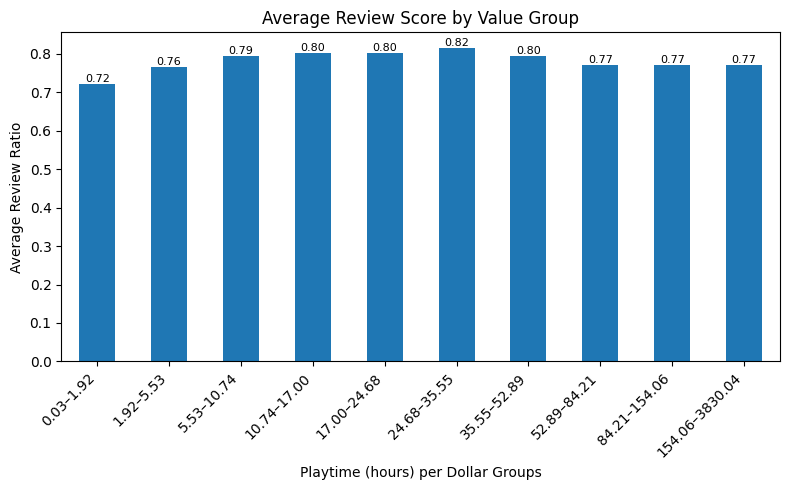

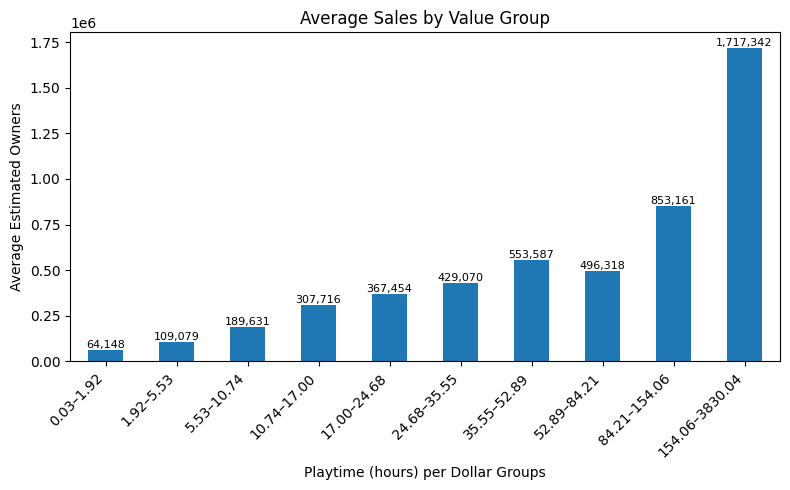

In [168]:
# Rounding the bar labels for Playtime/Price
def add_bar_labels(ax, values, fmt="{:.2f}"):
    for i, v in enumerate(values):
        ax.text(i, v, fmt.format(v), ha='center', va='bottom', fontsize=8)

# Calculation Playtime/Price
df_no_nan['playtime_per_dollar'] = df_no_nan['average_playtime_forever'] / (df_no_nan['price'] + 1)

# Removing extreme outliers
df_filtered = df_no_nan[df_no_nan['playtime_per_dollar'] <= df_no_nan['playtime_per_dollar'].quantile(0.99)].copy()

# Creating the bins & rounding to 2nd decimal point
df_filtered['value_group'] = pd.qcut(df_filtered['playtime_per_dollar'], 10, duplicates='drop')
df_filtered['value_group'] = df_filtered['value_group'].apply(lambda x: f"{x.left:.2f}–{x.right:.2f}")

# Group summaries
avg_review_by_value = df_filtered.groupby('value_group', observed=True)['review_ratio'].mean()
avg_owners_by_value = df_filtered.groupby('value_group', observed=True)['estimated_owners'].mean()

# --- Plot 1: Review Ratio ---
plt.figure(figsize=(8,5))
ax = avg_review_by_value.plot(kind='bar')

plt.xlabel("Playtime (hours) per Dollar Groups")
plt.ylabel("Average Review Ratio")
plt.title("Average Review Score by Value Group")
plt.xticks(rotation=45, ha='right')

add_bar_labels(ax, avg_review_by_value, "{:.2f}")

plt.tight_layout()
plt.show()

# --- Plot 2: Estimated Owners ---
plt.figure(figsize=(8,5))
ax = avg_owners_by_value.plot(kind='bar')

plt.xlabel("Playtime (hours) per Dollar Groups")
plt.ylabel("Average Estimated Owners")
plt.title("Average Sales by Value Group")
plt.xticks(rotation=45, ha='right')

# Use comma formatting for readability
add_bar_labels(ax, avg_owners_by_value, "{:,.0f}")

plt.tight_layout()
plt.show()

In [171]:
# Converting to html format
!jupyter nbconvert --to html Final_Project_CODE_Connor_Oman_example_execution.ipynb

[NbConvertApp] Converting notebook Final_Project_CODE_Connor_Oman_example_execution.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 1353988 bytes to Final_Project_CODE_Connor_Oman_example_execution.html
